In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import sklearn as skl
SaleFact = pd.read_csv('train (1).csv')
Geography = pd.read_csv('geography.csv')
Product = pd.read_csv('product.csv')
print(SaleFact.head())
print(Geography.head())
print(Product.head())


   ProductID        Date    Zip  Units    Revenue          COGS
0       1228  2013-07-31  78773     12   19648.44  12309.747660
1        781  2014-03-12  90501     16   20351.52  13497.128064
2       2090  2013-11-29  44460     26  111367.62  91488.499830
3       1116  2018-08-29  30122     12   36280.44  21967.806420
4        993  2013-04-27  75789     14   55557.18  48645.866808
     Zip            City State Region      District
0  15201  Pittsburgh, PA    PA   East  District #13
1  15202  Pittsburgh, PA    PA   East  District #13
2  15203  Pittsburgh, PA    PA   East  District #13
3  15204  Pittsburgh, PA    PA   East  District #13
4  15205  Pittsburgh, PA    PA   East  District #13
  Category      Segment        Product  ProductID
0    Urban  Convenience  Maximus UC-01        536
1    Urban  Convenience  Maximus UC-02        537
2    Urban  Convenience  Maximus UC-03        538
3    Urban  Convenience  Maximus UC-04        539
4    Urban  Convenience  Maximus UC-05        540


In [7]:
SaleFact['Date'] = pd.to_datetime(SaleFact['Date'])
SaleFact['Revenue'] = SaleFact['Revenue'].replace('[\$,]', '', regex=True).astype(float)
SaleFact['COGS'] = SaleFact['COGS'].replace('[\$,]', '', regex=True).astype(float)
SaleFact['Year'] = SaleFact['Date'].dt.year
SaleFact['Month'] = SaleFact['Date'].dt.month
SaleFact['year_month'] = SaleFact['Date'].dt.strftime('%Y-%m')
SaleFact['year_month'] = SaleFact['Date'].dt.to_period('M')
SaleFact['Quarter'] = SaleFact['Date'].dt.quarter
SaleFact = SaleFact.dropna(subset=['Revenue'])  
SaleFact = SaleFact[~SaleFact['Revenue'].isin([float('inf'), float('-inf')])]  
Product = Product.drop_duplicates(subset=['ProductID'])
Geography = Geography.drop_duplicates(subset=['Zip'])
# # Tìm giá trị trung bình của tháng 5 và tháng 6
# mean_revenue_5_6 = SaleFact.loc[SaleFact['year_month'].dt.to_timestamp().dt.month.isin([5, 6]), 'Revenue'].mean()

# # Thay thế Revenue của tháng 7 bằng giá trị trung bình này
# SaleFact.loc[SaleFact['year_month'].dt.month == 7, 'Revenue'] = mean_revenue_5_6

print(SaleFact.head())
print(Product.head())
print(Geography.head())

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20564\406117927.py:2: SyntaxWarning: invalid escape sequence '\$'
  SaleFact['Revenue'] = SaleFact['Revenue'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20564\406117927.py:3: SyntaxWarning: invalid escape sequence '\$'
  SaleFact['COGS'] = SaleFact['COGS'].replace('[\$,]', '', regex=True).astype(float)


   ProductID       Date    Zip  Units    Revenue          COGS  Year  Month year_month  Quarter
0       1228 2013-07-31  78773     12   19648.44  12309.747660  2013      7    2013-07        3
1        781 2014-03-12  90501     16   20351.52  13497.128064  2014      3    2014-03        1
2       2090 2013-11-29  44460     26  111367.62  91488.499830  2013     11    2013-11        4
3       1116 2018-08-29  30122     12   36280.44  21967.806420  2018      8    2018-08        3
4        993 2013-04-27  75789     14   55557.18  48645.866808  2013      4    2013-04        2
  Category      Segment        Product  ProductID
0    Urban  Convenience  Maximus UC-01        536
1    Urban  Convenience  Maximus UC-02        537
2    Urban  Convenience  Maximus UC-03        538
3    Urban  Convenience  Maximus UC-04        539
4    Urban  Convenience  Maximus UC-05        540
     Zip            City State Region      District
0  15201  Pittsburgh, PA    PA   East  District #13
1  15202  Pittsburgh

In [84]:

# # Chuyển đổi kiểu dữ liệu
# SaleFact['Date'] = pd.to_datetime(SaleFact['Date'])
# SaleFact['Revenue'] = SaleFact['Revenue'].replace('[\$,]', '', regex=True).astype(float)
# SaleFact['COGS'] = SaleFact['COGS'].replace('[\$,]', '', regex=True).astype(float)

# # Tạo các cột thời gian
# SaleFact['Year'] = SaleFact['Date'].dt.year
# SaleFact['Month'] = SaleFact['Date'].dt.month
# # SaleFact['year_month'] = SaleFact['Date'].dt.to_period('M')
# SaleFact['year_month'] = SaleFact['Date'].dt.to_period('M').dt.to_timestamp()
# SaleFact['Quarter'] = SaleFact['Date'].dt.quarter

# # Xử lý giá trị thiếu hoặc không hợp lệ
# SaleFact = SaleFact.dropna(subset=['Revenue'])  
# SaleFact = SaleFact[~SaleFact['Revenue'].isin([float('inf'), float('-inf')])]  

# # Xóa các bản ghi trùng lặp
# Product = Product.drop_duplicates(subset=['ProductID'])
# Geography = Geography.drop_duplicates(subset=['Zip'])

# # Tìm giá trị trung bình của tháng 5 và tháng 6
# mean_revenue_5_6 = SaleFact.loc[SaleFact['year_month'].dt.month.isin([5, 6]), 'Revenue'].mean()

# # Thay thế Revenue của tháng 7 bằng giá trị trung bình này vì giá trị Revenue quá béé
# SaleFact.loc[SaleFact['year_month'].dt.month == 7, 'Revenue'] = mean_revenue_5_6

# # Kiểm tra kết quả
# print(SaleFact.head())
# print(Product.head())
# print(Geography.head())

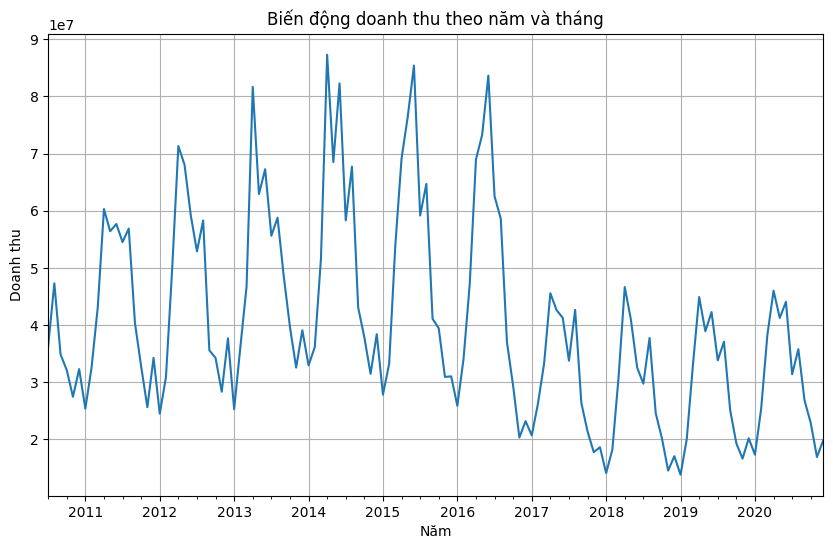

In [9]:
# revenue_by_year = SaleFact.groupby('Year')['Revenue'].sum()
# plt.figure(figsize=(10, 6))
# revenue_by_year.plot(kind='line', marker='o')
# plt.title('Xu hướng doanh thu theo năm')
# plt.xlabel('Năm')
# plt.ylabel('Doanh thu')
# plt.grid(True)
# plt.show()
revenue_by_year_month = SaleFact.groupby(['year_month'])['Revenue'].sum()
plt.figure(figsize=(10, 6))
revenue_by_year_month.plot(kind='line',marker='')
plt.title('Biến động doanh thu theo năm và tháng')
plt.xlabel('Năm')
plt.ylabel('Doanh thu')
plt.grid(True)
plt.show()

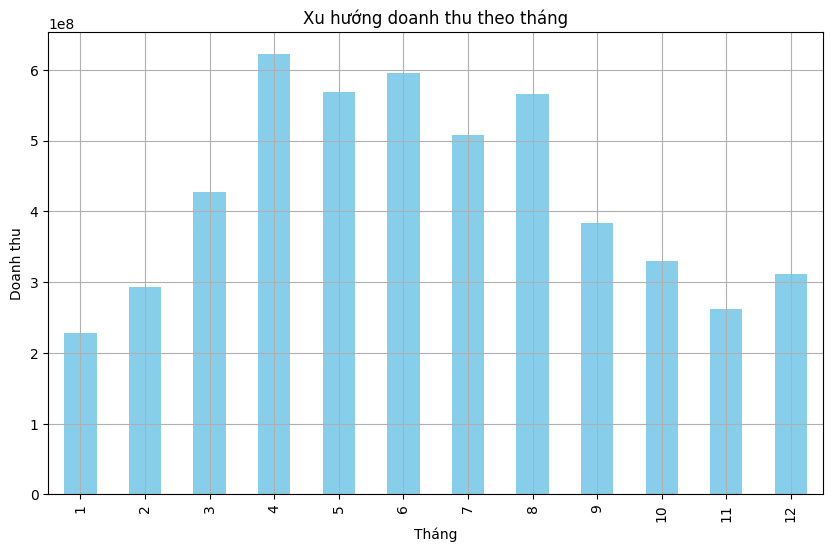

In [11]:
revenue_by_month = SaleFact.groupby('Month')['Revenue'].sum()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
revenue_by_month.plot(kind='bar', color='skyblue')
plt.title('Xu hướng doanh thu theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Doanh thu')
plt.grid(True)
plt.show()

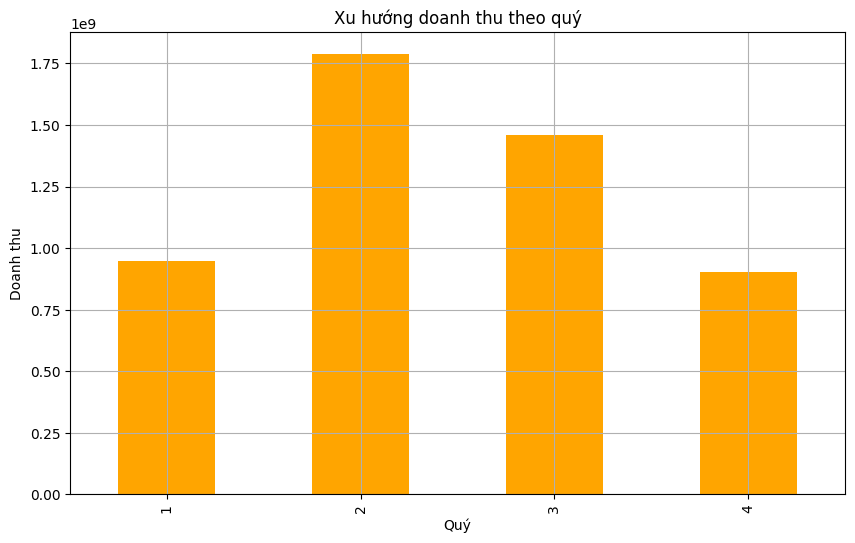

In [13]:
revenue_by_quarter = SaleFact.groupby('Quarter')['Revenue'].sum()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
revenue_by_quarter.plot(kind='bar', color='orange')
plt.title('Xu hướng doanh thu theo quý')
plt.xlabel('Quý')
plt.ylabel('Doanh thu')
plt.grid(True)
plt.show()

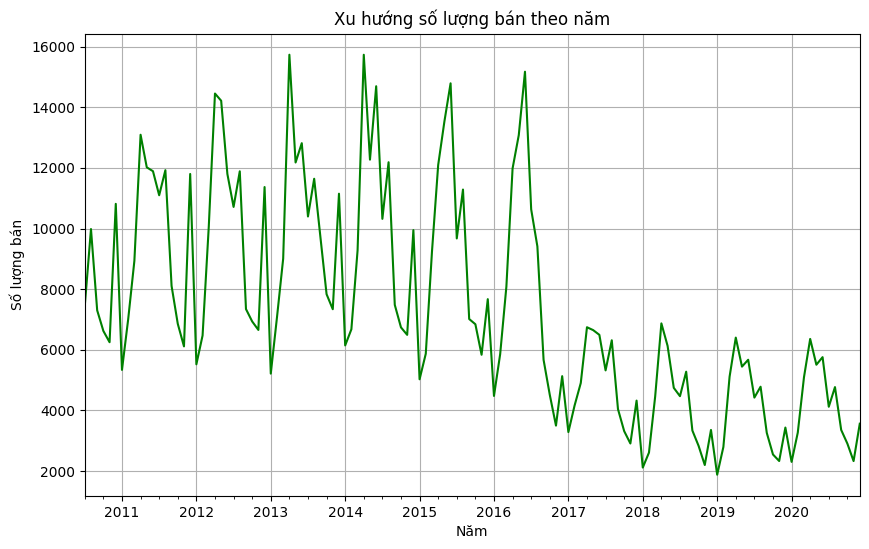

In [15]:
# Tính tổng số lượng bán theo năm
units_by_year = SaleFact.groupby('year_month')['Units'].sum()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
units_by_year.plot(kind='line', marker='', color='green')
plt.title('Xu hướng số lượng bán theo năm')
plt.xlabel('Năm')
plt.ylabel('Số lượng bán')
plt.grid(True)
plt.show()

     Zip            City State Region      District  ...          COGS    Year  Month  year_month  Quarter
0  15201  Pittsburgh, PA    PA   East  District #13  ...   4038.346935  2013.0    7.0     2013-07      3.0
1  15201  Pittsburgh, PA    PA   East  District #13  ...   9915.469200  2010.0    7.0     2010-07      3.0
2  15201  Pittsburgh, PA    PA   East  District #13  ...   9998.525250  2012.0   11.0     2012-11      4.0
3  15201  Pittsburgh, PA    PA   East  District #13  ...  10995.739587  2020.0    7.0     2020-07      3.0
4  15201  Pittsburgh, PA    PA   East  District #13  ...   3016.227060  2015.0    4.0     2015-04      2.0

[5 rows x 14 columns]


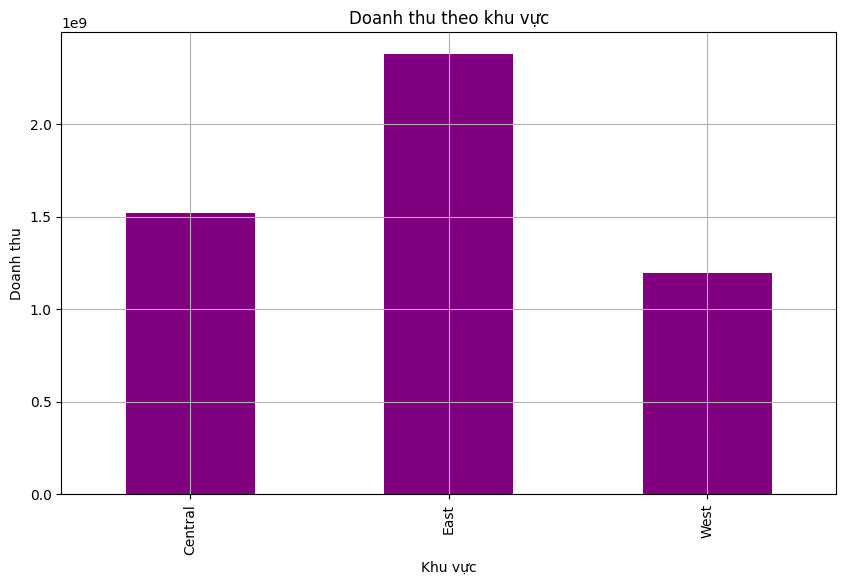

In [17]:
SaleFact_Geo = Geography.merge(SaleFact, how= "left",on="Zip")
print(SaleFact_Geo.head())
# Tính tổng doanh thu theo khu vực
revenue_by_region = SaleFact_Geo.groupby('Region')['Revenue'].sum()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
revenue_by_region.plot(kind='bar', color='purple')
plt.title('Doanh thu theo khu vực')
plt.xlabel('Khu vực')
plt.ylabel('Doanh thu')
plt.grid(True)
plt.show()

       Category       Segment        Product  ProductID       Date  ...          COGS    Year  Month  year_month  Quarter
0         Urban   Convenience  Maximus UC-01        536 2013-02-19  ...  19409.685750  2013.0    2.0     2013-02      1.0
1         Urban   Convenience  Maximus UC-01        536 2013-02-22  ...  19409.685750  2013.0    2.0     2013-02      1.0
2         Urban   Convenience  Maximus UC-01        536 2013-04-26  ...   9704.842875  2013.0    4.0     2013-04      2.0
3         Urban   Convenience  Maximus UC-01        536 2013-04-10  ...   9704.842875  2013.0    4.0     2013-04      2.0
4         Urban   Convenience  Maximus UC-01        536 2013-06-10  ...   9704.842875  2013.0    6.0     2013-06      2.0
...         ...           ...            ...        ...        ...  ...           ...     ...    ...         ...      ...
902344      Mix  Productivity   Quibus MP-32       1264 2020-03-24  ...   3719.884392  2020.0    3.0     2020-03      1.0
902345      Mix  Product

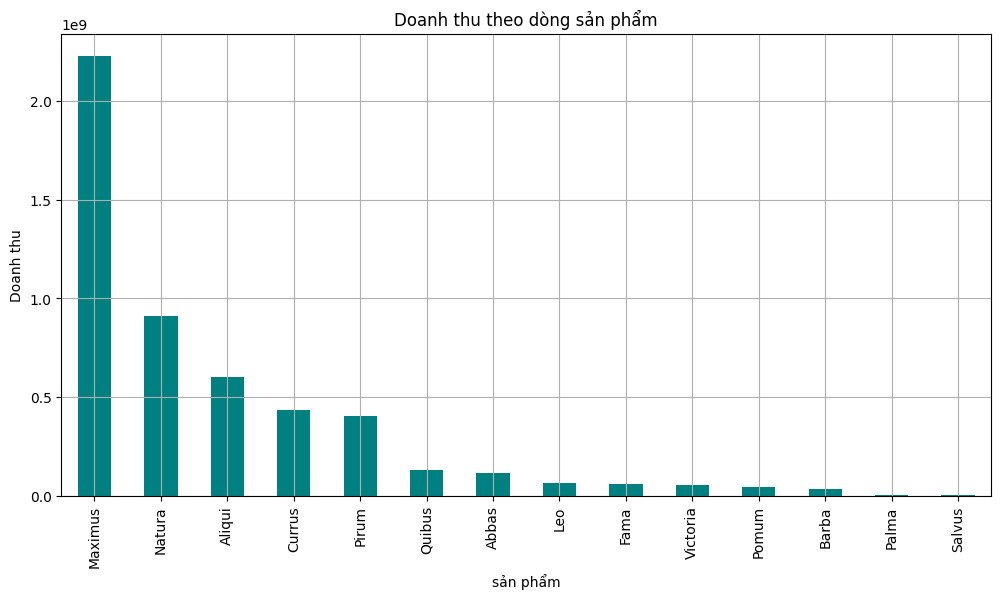

In [19]:
SaleFact_Product = Product.merge(SaleFact, how='left',on="ProductID")
print(SaleFact_Product)
SaleFact_Product['Partition'] = SaleFact_Product['Product'].str.extract(r'^(\w+)')
# Tính tổng doanh thu theo dòng sản phẩm
revenue_by_product = SaleFact_Product.groupby('Partition')['Revenue'].sum()

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
revenue_by_product.sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('Doanh thu theo dòng sản phẩm')
plt.xlabel('sản phẩm')
plt.ylabel('Doanh thu')
plt.grid(True)
plt.show()

In [20]:

# sampled_data = SaleFact['Revenue'].sample(n=3000, random_state=45)
# print(test_result)

# def adfuller_test(Revenue):
#     result=adfuller(Revenue)
#     labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
#     for value,label in zip(result,labels):
#         print(label+' : '+str(value) )
#     if result[1] <= 0.05:
#         print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
#     else:
#         print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")
def adfuller_test(series, name=""):
    """Hàm kiểm tra tính dừng của chuỗi thời gian"""
    result = adfuller(series, autolag='AIC')
    labels = ["ADF Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"]
    output = dict(zip(labels, result[:4]))
    
    print(f"\n Kiểm tra tính dừng của {name if name else 'chuỗi dữ liệu'}:")
    for key, value in output.items():
        print(f"🔹 {key}: {value:.6f}")
    
    if result[1] <= 0.05:
        print(" Dữ liệu đã dừng (Reject Ho)")
        return True
    else:
        print(" Dữ liệu không dừng (Fail to Reject Ho)")
        return False

def make_stationary(series, max_d=3):
    """Tự động xác định mức sai phân cần thiết để làm cho chuỗi thời gian dừng"""
    diff_level = 0
    temp_series = series.copy()
    
    while diff_level < max_d:
        if adfuller_test(temp_series, name=f"Dữ liệu sau sai phân bậc {diff_level}"):
            break
        temp_series = temp_series.diff().dropna()
        diff_level += 1
    
    return temp_series, diff_level
# sampled_data_diff = sampled_data.diff().dropna()
# adfuller_test(sampled_data_diff)
# sampled_data = SaleFact['Revenue'].iloc[-100000:]

# Kiểm tra và làm dừng dữ liệu nếu cần
# stationary_data, diff_used = make_stationary(sampled_data)
# print(diff_used)
# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
# plt.plot(sampled_data)
# plt.title("Dữ liệu gốc")

# plt.subplot(1,2,2)
# plt.plot(stationary_data)
# plt.title("Dữ liệu sau khi sai phân bậc diff_used")
# plt.show()



 Kiểm tra tính dừng của Dữ liệu sau sai phân bậc 0:
🔹 ADF Test Statistic: -0.603644
🔹 p-value: 0.870156
🔹 #Lags Used: 12.000000
🔹 Number of Observations Used: 113.000000
 Dữ liệu không dừng (Fail to Reject Ho)

 Kiểm tra tính dừng của Dữ liệu sau sai phân bậc 1:
🔹 ADF Test Statistic: -4.117726
🔹 p-value: 0.000905
🔹 #Lags Used: 11.000000
🔹 Number of Observations Used: 113.000000
 Dữ liệu đã dừng (Reject Ho)
Số bậc sai phân đã sử dụng: 1


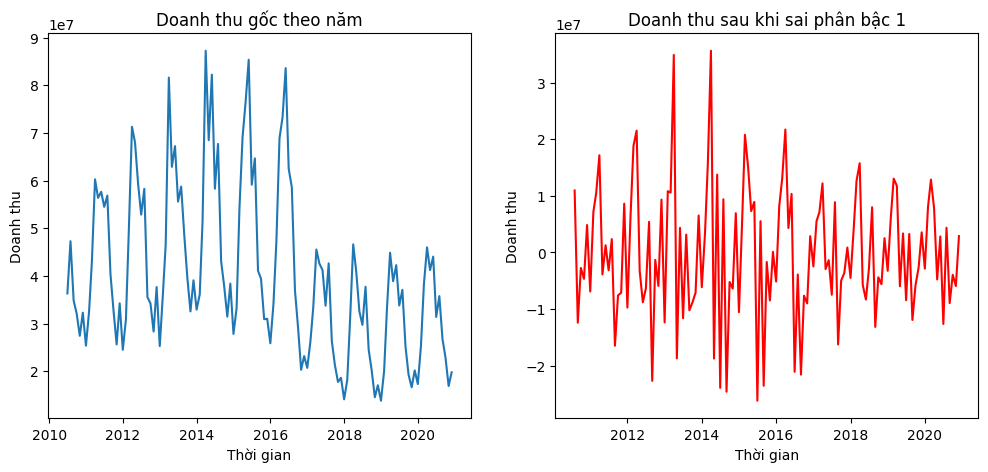

In [21]:
# Chuyển year_month từ Period thành Datetime
SaleFact['year_month'] = SaleFact['year_month'].dt.to_timestamp()

# Gom nhóm theo year_month
sampled_data = SaleFact.groupby('year_month')['Revenue'].sum()

# Chuyển index từ PeriodIndex sang DatetimeIndex nếu cần
if isinstance(sampled_data.index, pd.PeriodIndex):
    sampled_data.index = sampled_data.index.to_timestamp()

# Làm chuỗi dữ liệu trở thành stationarity
stationary_data, diff_used = make_stationary(sampled_data)

# Chuyển index của stationary_data nếu cần
if isinstance(stationary_data.index, pd.PeriodIndex):
    stationary_data.index = stationary_data.index.to_timestamp()

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))
print(f"Số bậc sai phân đã sử dụng: {diff_used}")

# Biểu đồ doanh thu gốc
plt.subplot(1, 2, 1)
plt.plot(sampled_data.index, sampled_data.values, marker='', linestyle='-')
plt.title("Doanh thu gốc theo năm")
plt.xlabel("Thời gian")
plt.ylabel("Doanh thu")

# Biểu đồ doanh thu sau khi sai phân
plt.subplot(1, 2, 2)
plt.plot(stationary_data.index, stationary_data.values, marker='', linestyle='-', color='red')
plt.title(f"Doanh thu sau khi sai phân bậc {diff_used}")
plt.xlabel("Thời gian")
plt.ylabel("Doanh thu")

plt.show()

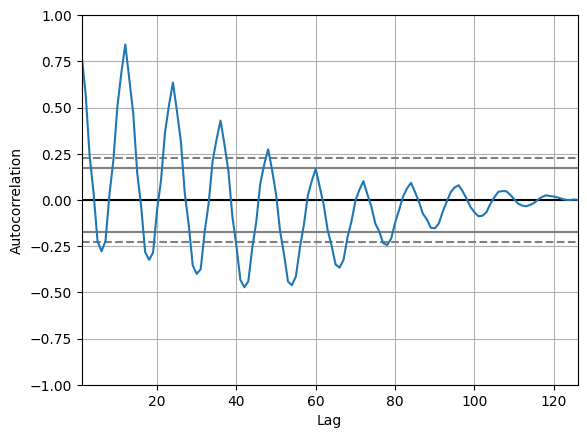

In [25]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(sampled_data)
plt.show()

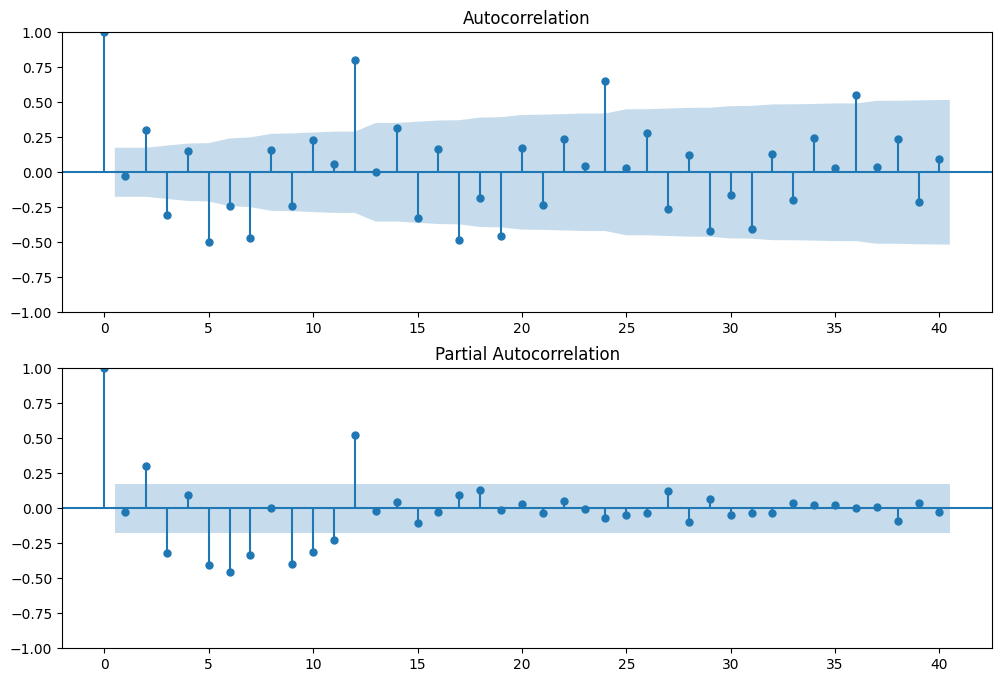

In [27]:
import statsmodels.api as sm
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(stationary_data,lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(stationary_data,lags=40,ax=ax2)

In [30]:
# p = 1 hoặc 2. q = 2 hoặc 3
from statsmodels.tsa.arima.model import ARIMA 
# SaleFact_yearly = SaleFact.groupby('Year')['Revenue'].sum()
# model = ARIMA(SaleFact_yearly,order =(1,1,1))
# model_fit = model.fit()
# forecast = model_fit.predict(start=len(SaleFact_yearly), end=len(SaleFact_yearly) + future_years - 1, dynamic=True)
# from statsmodels.tsa.arima.model import ARIMA
SaleFact['year_month'] = SaleFact['Date'].dt.to_period('M')
SaleFact_yearly = SaleFact.groupby('year_month')['Revenue'].sum()

# Chuyển đổi chỉ mục thành kiểu datetime để có thể cắt lát theo năm
SaleFact_yearly.index = SaleFact_yearly.index.to_timestamp()

# Chia tập train (2012-2020) và tập test (2020-2022)
train = SaleFact_yearly.loc['2010-01-01':'2020-12-31']
test = SaleFact_yearly.loc['2020-12-31':'2022-06-30'] # tháng 7 có chỉ số Revenue không đầy đủ

# Xây dựng mô hình ARIMA trên tập train
model = ARIMA(train, order=(2, 1, 3))
model_fit = model.fit()

# Dự đoán trên tập test
forecast_steps = len(test)
forecast = model_fit.forecast(steps=forecast_steps)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train.index, train, label='Train (2010-2020)', color='blue')
plt.plot(test.index, test, label='Test (2020-2022)', color='green')
plt.plot(test.index, forecast, label='Dự đoán (2020-2022)', color='red', linestyle='--')
plt.title('Dự đoán doanh thu theo năm')
plt.xlabel('Năm')
plt.ylabel('Doanh thu')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\ASUS\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ValueError: Prediction must have `end` after `start`.

In [ ]:

# forecast = model_fit.predict(start=len(SaleFact_yearly), end=len(SaleFact_yearly) + future_years - 1, dynamic=True)
# # Tạo trục thời gian cho dự báo
# forecast_index = pd.date_range(start=SaleFact_yearly.index[-1] + pd.DateOffset(years=1), periods=future_years, freq='Y')

# # Vẽ biểu đồ
# plt.figure(figsize=(12,6))
# plt.plot(SaleFact_yearly.index, SaleFact_yearly, label='Doanh thu thực tế', marker='o')
# plt.plot(forecast_index, forecast, label='Dự báo ARIMA', linestyle='dashed', marker='o', color='red')

# # Thêm tiêu đề và nhãn trục
# plt.title("Dự báo doanh thu theo năm")
# plt.xlabel("Năm")
# plt.ylabel("Doanh thu")
# plt.legend()
# plt.grid(True)

# # Hiển thị biểu đồ
# plt.show()

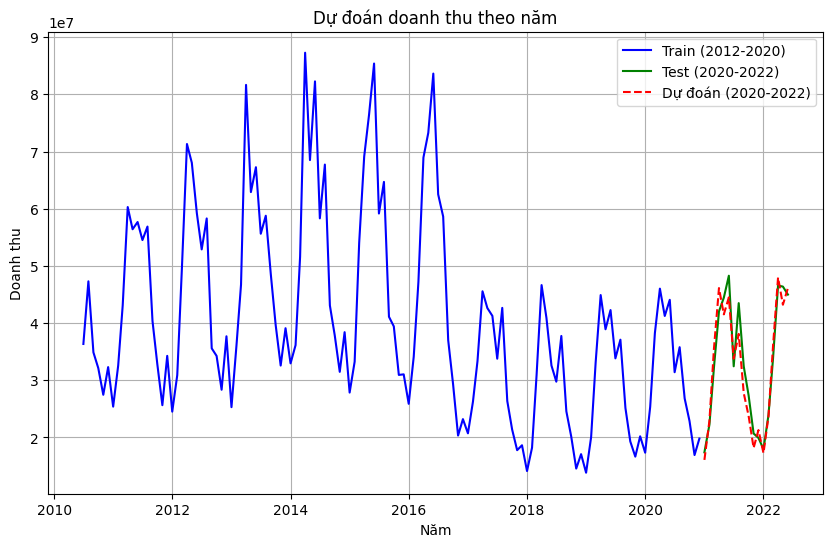

In [144]:
#P =1 hoặc 2. Q = 1 hoặc 22
import statsmodels.api as sm
model1=sm.tsa.statespace.SARIMAX(train,order=(2, 1, 3),seasonal_order=(1,1,1,12))
results=model1.fit()
forecast_steps1 = len(test)
forecast1 = results.forecast(steps=forecast_steps)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(train.index, train, label='Train (2012-2020)', color='blue')
plt.plot(test.index, test, label='Test (2020-2022)', color='green')
plt.plot(test.index, forecast1, label='Dự đoán (2020-2022)', color='red', linestyle='--')
plt.title('Dự đoán doanh thu theo năm')
plt.xlabel('Năm')
plt.ylabel('Doanh thu')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# from pmdarima import auto_arima

# stepwise_model = auto_arima(train, seasonal=False, m=12, trace=True,
#                             error_action='ignore', suppress_warnings=True)
# print(stepwise_model.summary())

In [145]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Tính R-Squared (R²)
r2 = r2_score(test, forecast)
print(f" R-Squared (R²): {r2:.4f}")

# Tính Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((test - forecast) / test)) * 100
print(f"MAPE: {mape:.2f}%")

# Tính Root Mean Square Error (RMSE)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f" RMSE: {rmse:.4f}")

 R-Squared (R²): -0.0849
MAPE: 29.18%
 RMSE: 11212257.8496


In [146]:
r2 = r2_score(test, forecast1)
print(f" R-Squared (R²): {r2:.4f}")

# Tính Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((test - forecast1) / test)) * 100
print(f"MAPE: {mape:.2f}%")

# Tính Root Mean Square Error (RMSE)
rmse = np.sqrt(mean_squared_error(test, forecast1))
print(f" RMSE: {rmse:.4f}")

 R-Squared (R²): 0.9305
MAPE: 7.31%
 RMSE: 2837348.0608
